<a href="https://colab.research.google.com/github/harunsy/LogisticRegression.ipynb/blob/main/DBSCAN%20Clustering/DBSCAN_mall_customer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial: DBSCAN Clustering dengan Mall Customer Dataset

Di tutorial ini kita akan belajar mengelompokkan pelanggan sebuah mall berdasarkan **pendapatan tahunan** (`Annual Income`) dan **skor belanja** (`Spending Score`) menggunakan **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)**.


**Apa itu DBSCAN (singkat)?**
DBSCAN mengelompokkan data berdasarkan **kepadatan** (density). Titik-titik yang berkumpul rapat dianggap satu cluster, sedangkan titik yang berdiri sendiri jauh dari kerumunan ditandai sebagai **noise (outlier)**. Dua hal yang membedakan DBSCAN dari K-Means atau Hierarchical Clustering:

- Kita **tidak perlu menentukan jumlah cluster** di awal.
- DBSCAN bisa **mendeteksi outlier** secara otomatis.

DBSCAN diatur oleh dua parameter:
- `eps`: radius pencarian tetangga di sekitar sebuah titik.
- `min_samples`: jumlah minimal titik dalam radius `eps` agar sebuah titik dianggap berada di area padat.

**Library:** Python 3 dengan `pandas`, `numpy`, `matplotlib`, dan `scikit-learn`.


## 1. Import Library dan Load Data

Kita mulai dengan mengimpor library yang dipakai, lalu membaca dataset langsung dari URL menggunakan `pandas`. Setelah data dimuat, kita cek ukurannya dan lima baris pertama untuk memastikan data terbaca dengan benar.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

In [ ]:
url = 'https://gist.github.com/pravalliyaram/5c05f43d2351249927b8a3f3cc3e5ecf/raw/8bd6144a87988213693754baaa13fb204933282d/Mall_Customers.csv'
data = pd.read_csv(url)
print("Dataset shape:", data.shape)
data.head()

Dataset shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 2. Memahami Dataset

Sebelum clustering, kenali dulu datanya. Mulai dari informasi singkat: berapa baris, nama kolom, dan tipe datanya.


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


Kemudian tampilkan statistik deskriptif (rata-rata, nilai minimum dan maksimum, dan sebaran) untuk kolom numerik.


In [ ]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## 3. Memilih Fitur

Untuk tutorial ini kita hanya memakai dua fitur, supaya hasilnya mudah divisualisasikan dalam grafik 2 dimensi:

- `Annual Income (k$)`
- `Spending Score (1-100)`


In [ ]:
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


## 4. Visualisasi Data

Sebelum melakukan clustering, mari lihat sebaran data dengan *scatter plot* agar terlihat pola awalnya.


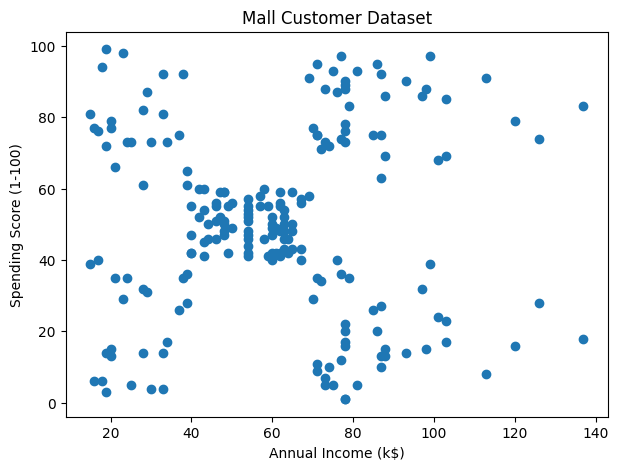

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)']
)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Mall Customer Dataset")
plt.show()

Amati bagaimana data tersebar. Apakah anda dapat memperkirakan ada beberapa kelompok pelanggan?


## 5. Standardisasi Data

DBSCAN bekerja berdasarkan **jarak** antar data. Jika satu fitur memiliki rentang angka yang jauh lebih besar dari fitur lain, fitur itu akan mendominasi perhitungan jarak. Karena itu data perlu **distandardisasi** agar kedua fitur memiliki skala yang sama (rata-rata 0 dan simpangan baku 1).


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 6. Membuat Model DBSCAN

Sekarang kita buat model DBSCAN. Pada tutorial ini kita memakai parameter berikut:

- `eps = 0.35`: radius pencarian tetangga.
- `min_samples = 5`: jumlah minimal tetangga agar dianggap area padat.

Method `fit_predict` akan mengembalikan **label cluster** untuk setiap pelanggan.


In [ ]:
dbscan = DBSCAN(
    eps=0.35,
    min_samples=5
)
clusters = dbscan.fit_predict(X_scaled)

Lihat label cluster yang dihasilkan.


In [ ]:
print(clusters)

[ 2  0  1  0  2  0  1 -1  1  0  1 -1  1  0  1  0  2  0  2 -1  2  0  1  0
  1  0  2  0  2  0  1  0  1 -1  1  0  1  0 -1  0  3 -1  3  3  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  3  3  4  3  4  3  4  5  4  5  4  3  4  5  4  5  4  5  4  5  4  3  4
  5  4  3  4  5  4  5  4  5  4  5  4  5  4  5  4  3  4  5  4  5  4  5  4
  5 -1  5  4  5  4  5  4  5  4  5  4 -1  4  5  4 -1 -1 -1 -1 -1  4 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1]


Keterangan:
- `0, 1, 2, ...` menunjukkan nomor cluster.
- `-1` menunjukkan **noise (outlier)**, yaitu titik yang tidak masuk cluster mana pun.


## 7. Menambahkan Hasil Cluster ke Dataset

Agar mudah dianalisis, kita tambahkan label cluster sebagai kolom baru di DataFrame.


In [ ]:
data['Cluster'] = clusters
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,0
2,3,Female,20,16,6,1
3,4,Female,23,16,77,0
4,5,Female,31,17,40,2


Lihat jumlah anggota setiap cluster.


In [ ]:
data['Cluster'].value_counts()

,count
Cluster,
3,88
4,31
-1,23
5,23
0,16
1,12
2,7


## 8. Visualisasi Hasil Clustering

Kita gambar ulang scatter plot, tetapi sekarang setiap pelanggan diwarnai sesuai label cluster-nya.


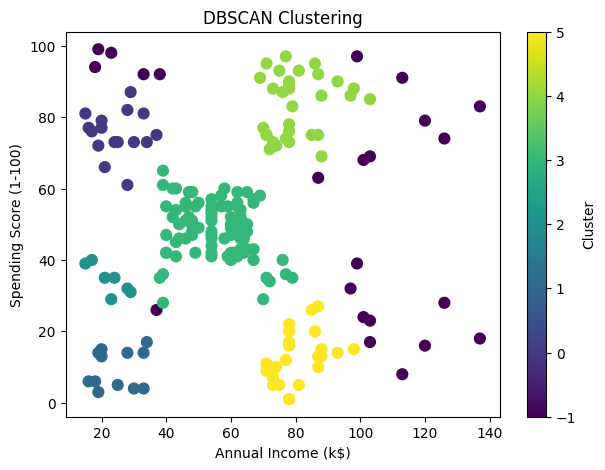

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)'],
    c=data['Cluster'],
    cmap='viridis',
    s=60
)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("DBSCAN Clustering")
plt.colorbar(label="Cluster")
plt.show()

Perhatikan bahwa setiap warna menunjukkan cluster yang berbeda. Jika terdapat titik dengan label `-1`, maka titik tersebut dianggap sebagai **noise**.


## 9. Melihat Karakteristik Setiap Cluster

Label angka belum berarti apa-apa sampai kita menafsirkannya. Kita hitung rata-rata income dan spending score per cluster untuk memahami karakter tiap kelompok.


In [ ]:
data.groupby('Cluster')[['Annual Income (k$)',
                         'Spending Score (1-100)']].mean()

,Annual Income (k$),Spending Score (1-100)
Cluster,,
-1,89.260870,57.826087
0,24.750000,75.375000
1,24.583333,9.583333
2,22.428571,34.428571
3,55.227273,48.579545
4,80.290323,83.193548
5,80.956522,12.782609


Hitung juga jumlah pelanggan pada setiap cluster (diurutkan berdasarkan nomor cluster).


In [ ]:
data['Cluster'].value_counts().sort_index()

,count
Cluster,
-1,23
0,16
1,12
2,7
3,88
4,31
5,23


## 10. Kesimpulan

Pada tutorial ini kita telah berhasil melakukan clustering menggunakan DBSCAN.

Hal-hal penting yang dapat dipelajari:
- DBSCAN tidak perlu menentukan jumlah cluster di awal.
- DBSCAN dapat menemukan noise atau outlier (label `-1`).
- Hasil clustering dipengaruhi oleh parameter `eps` dan `min_samples`.
- Standardisasi data penting karena DBSCAN menggunakan perhitungan jarak.


## Latihan

Kerjakan latihan berikut di sel kode kosong yang tersedia. Semua latihan bisa diselesaikan dengan teknik yang sudah dipakai di atas.

**Latihan 1.** Ubah nilai `eps` menjadi `0.25`. Apa yang terjadi pada jumlah cluster?


In [ ]:
# Tulis kode anda di sini


**Latihan 2.** Ubah nilai `eps` menjadi `0.50`. Apa perbedaannya dibanding hasil sebelumnya?


In [ ]:
# Tulis kode anda di sini


**Latihan 3.** Ubah nilai `min_samples` menjadi `3`. Bandingkan hasilnya.


In [ ]:
# Tulis kode anda di sini


**Latihan 4.** Coba gunakan fitur `Age` dan `Spending Score (1-100)` (jangan lupa standardisasi ulang). Apakah hasil clustering berubah?


In [ ]:
# Tulis kode anda di sini


**Latihan 5 (analisis).** Menurutmu, mengapa DBSCAN menghasilkan beberapa data dengan label `-1`? Tulis jawabanmu sebagai komentar atau di sel markdown baru.


In [ ]:
# Tulis jawaban anda di sini
